# Optimizing and Deploying a CNN Image Classifier on Edge Devices

**Final project walkthrough.** This notebook loads the already-trained model and
converted TFLite variants produced by `src/train.py`, `src/convert.py`, and
`src/benchmark.py`, and walks through the pipeline end to end: data, model
architecture, training result, conversion, benchmark, and single-image inference.

Every number and image in this notebook is loaded from real artifacts produced
by actually running the pipeline scripts in `src/` -- nothing here is re-typed
or invented.

In [1]:
import os
import sys

import numpy as np
import tensorflow as tf
from IPython.display import Image, display

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
sys.path.insert(0, os.path.join(PROJECT_ROOT, "src"))

from data import load_data, CLASS_NAMES

print("TensorFlow version:", tf.__version__)
print("Class names:", CLASS_NAMES)

TensorFlow version: 2.21.0
Class names: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 1. Data

In [2]:
data = load_data()
for key, arr in data.items():
    print(f"{key}: shape={arr.shape}, dtype={arr.dtype}")

x_train: shape=(54000, 28, 28, 1), dtype=float32
y_train: shape=(54000,), dtype=uint8
x_val: shape=(6000, 28, 28, 1), dtype=float32
y_val: shape=(6000,), dtype=uint8
x_test: shape=(10000, 28, 28, 1), dtype=float32
y_test: shape=(10000,), dtype=uint8


## 2. Model architecture

26,154 parameters -- fewer than half of the earlier `tensorflow-basics/` CNN
(56,714 params), thanks to `GlobalAveragePooling2D` replacing a large `Flatten`+`Dense`
layer (see `tensorflow-basics/README.md` for why that layer dominated parameter count there).

In [3]:
model_path = os.path.join(PROJECT_ROOT, "models", "cnn_classifier.keras")
model = tf.keras.models.load_model(model_path)
model.summary()
print(f"\nTotal parameters: {model.count_params():,}")

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 78,016 (304.75 KB)

 Trainable params: 25,930 (101.29 KB)

 Non-trainable params: 224 (896.00 B)

 Optimizer params: 51,862 (202.59 KB)


Total parameters: 26,154


## 3. Training result

Trained with early stopping on validation accuracy (`restore_best_weights=True`) after
an initial run showed epoch-to-epoch validation instability -- see `src/train.py`'s
comments for the real reasoning.

Final test accuracy: 0.9007
Final test loss: 0.2824


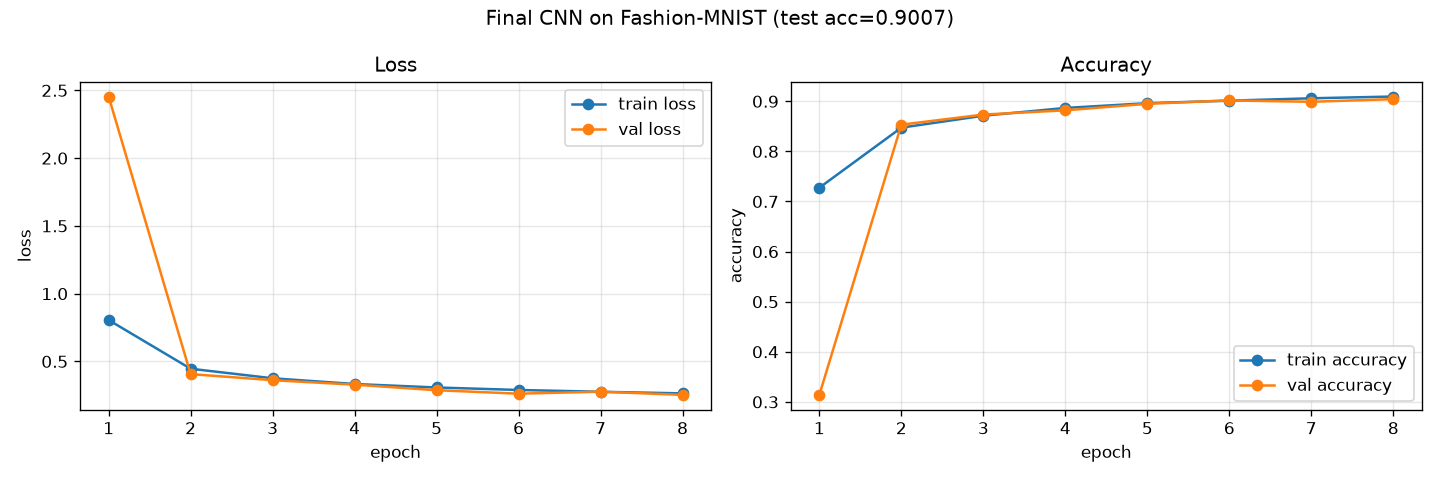

In [4]:
test_loss, test_acc = model.evaluate(data["x_test"], data["y_test"], verbose=0)
print(f"Final test accuracy: {test_acc:.4f}")
print(f"Final test loss: {test_loss:.4f}")

display(Image(filename=os.path.join(PROJECT_ROOT, "results", "training_curve.png")))

## 4. Confusion matrix (float32 model, full test set)

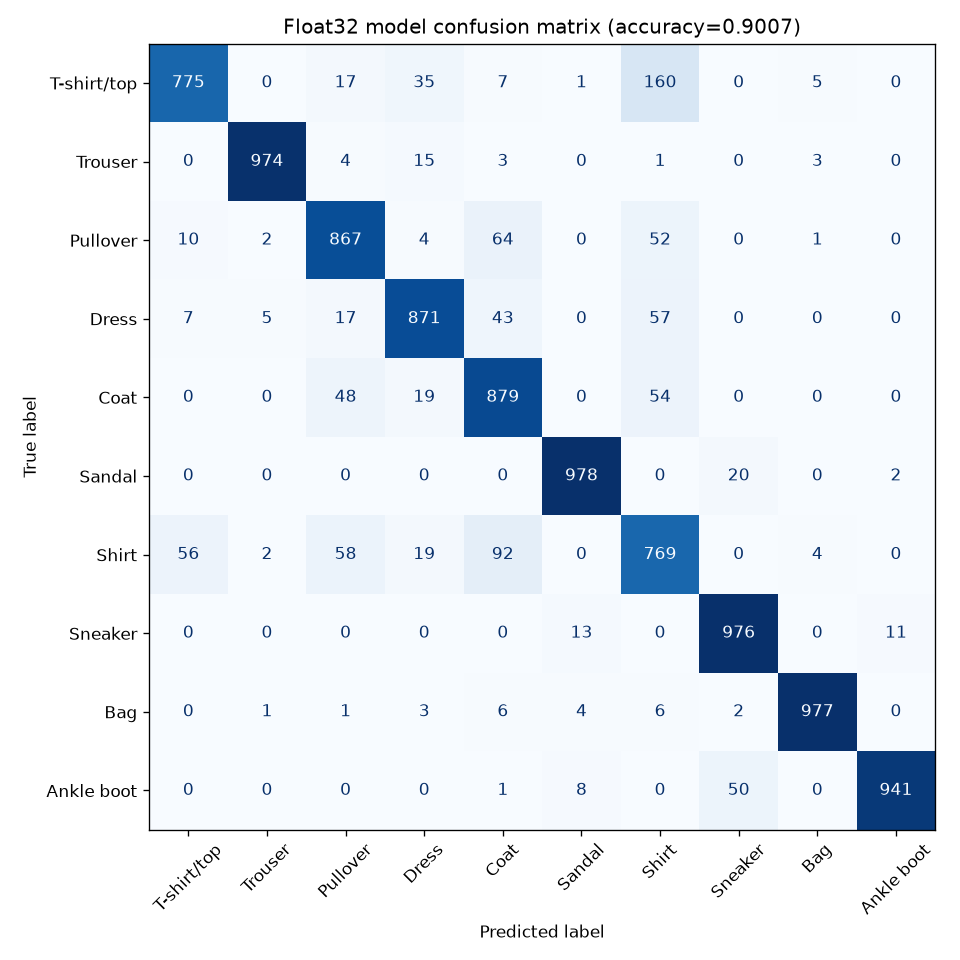

In [5]:
display(Image(filename=os.path.join(PROJECT_ROOT, "results", "confusion_matrix.png")))

The confusion matrix shows the expected Fashion-MNIST confusion cluster: Shirt,
T-shirt/top, Pullover, and Coat get confused with each other far more than with
anything else (e.g. Trouser or Sandal) -- these classes really do look visually
similar at 28x28 grayscale resolution.

## 5. TFLite conversion and benchmark

Three variants converted by `src/convert.py`: float32 baseline, dynamic-range
quantized, and full-integer INT8 (calibrated on 100 real training images).

| Model | Size (KB) | Accuracy | Mean latency (ms/image) |
|---|---|---|---|
| float32 | 107.32 | 0.9007 | 0.2439 |
| dynamic_range | 35.42 | 0.9014 | 0.1517 |
| int8 | 36.41 | 0.8589 | 0.2056 |



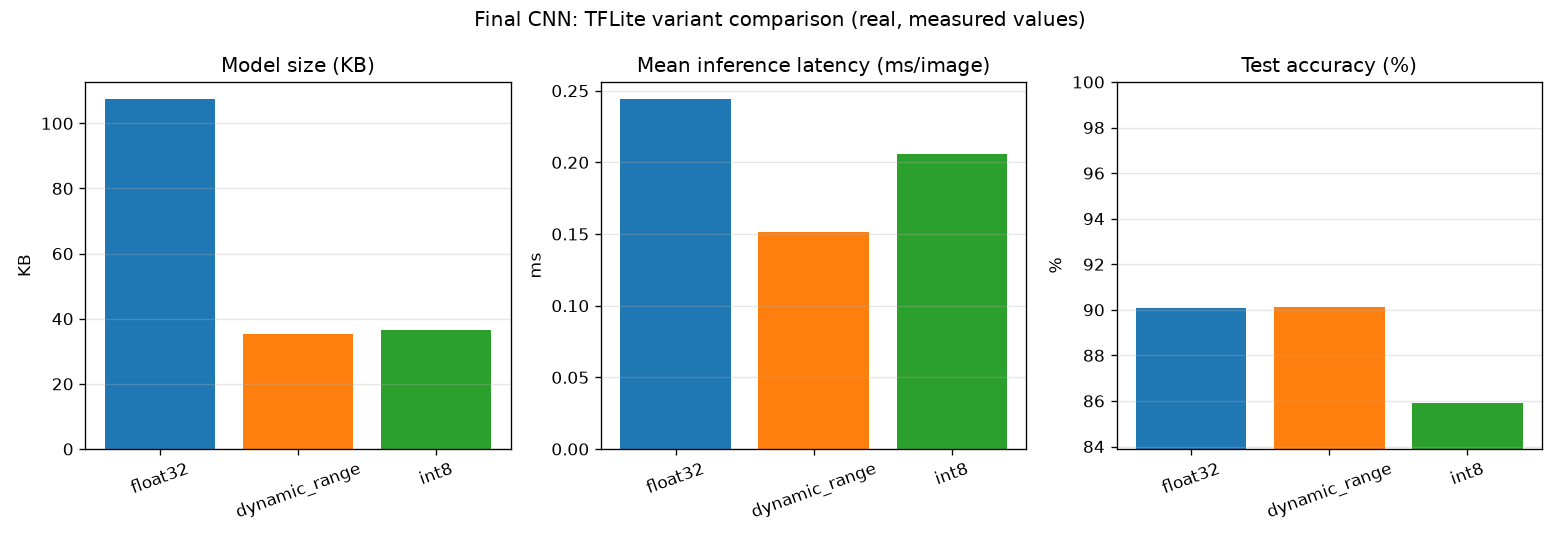

In [6]:
with open(os.path.join(PROJECT_ROOT, "results", "benchmark_table.md")) as f:
    print(f.read())

display(Image(filename=os.path.join(PROJECT_ROOT, "results", "comparison_chart.png")))

**Real finding:** unlike the simpler CNN in `tensorflow-basics/`/`tensorflow-lite/`
(where INT8 accuracy loss was negligible, <0.2 percentage points), this deeper
model with `BatchNormalization` layers saw a real ~4.2 percentage point accuracy
drop under full INT8 quantization (90.07% -> 85.89%). BatchNorm's learned scale/shift
parameters and running statistics add another source of quantization error on top of
the convolutional weights, which the simpler, BatchNorm-free model didn't have.

## 6. Single-image inference, via `src/infer.py`'s TFLite pipeline

In [7]:
from infer import predict

clean_image = os.path.join(PROJECT_ROOT, "results", "test_sample_correct.png")
display(Image(filename=clean_image))

for variant in ["float32", "dynamic_range", "int8"]:
    model_path = os.path.join(PROJECT_ROOT, "models", f"model_{variant}.tflite")
    label, confidence = predict(clean_image, model_path)
    print(f"{variant:15s}: predicted={label:15s} confidence={confidence:.4f}")

float32        : predicted=Ankle boot      confidence=0.9994
dynamic_range  : predicted=Ankle boot      confidence=0.9995
int8           : predicted=Ankle boot      confidence=0.9961


C:\Users\Piyush\drdo-edge-ai-internship\venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


True label for this test image is **Ankle boot** -- all three model variants agree, correctly, with high confidence.

In [8]:
ambiguous_image = os.path.join(PROJECT_ROOT, "results", "test_sample_ambiguous.png")
display(Image(filename=ambiguous_image))

for variant in ["float32", "dynamic_range", "int8"]:
    model_path = os.path.join(PROJECT_ROOT, "models", f"model_{variant}.tflite")
    label, confidence = predict(ambiguous_image, model_path)
    print(f"{variant:15s}: predicted={label:15s} confidence={confidence:.4f}")

float32        : predicted=Coat            confidence=0.4283
dynamic_range  : predicted=Coat            confidence=0.4537
int8           : predicted=Dress           confidence=0.4297


True label for this one is **Dress**. float32 and dynamic-range both confidently
(ish) predict Coat instead; int8 happens to land on the correct answer. All three
confidences are under 50% -- this is a genuinely ambiguous example (a coat and a
dress at 28x28 grayscale resolution can look very similar), not a bug in any
model. Kept in this notebook deliberately, because a real project should show a
failure/ambiguous case honestly, not just its best result.

## Summary

- Trained a 26,154-parameter CNN to 90.07% test accuracy on Fashion-MNIST.
- Converting to TFLite shrank the model from 107.32 KB (float32) to ~35-36 KB
  (dynamic-range / INT8) -- about 3x smaller.
- Dynamic-range quantization was effectively free (accuracy actually ticked up
  slightly, 90.07% -> 90.14%) and was also the fastest variant on this CPU.
- Full INT8 quantization cost a real, measurable ~4.2 percentage points of
  accuracy on this BatchNorm-containing architecture -- a genuine tradeoff,
  not the near-free result seen on the simpler CNN elsewhere in this repo.
- See `reports/final-report.md` for the full writeup and
  `raspberry-pi/README.md` for what is and isn't verified on real edge hardware.